In [18]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import json
import datasets
import matplotlib.pyplot as plt
import torch
import numpy as np
import PIL
import albumentations as A


from project_root import DATASETS_ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


v1/good/zag_elp_cam_018/ZAG-ELP-CAM-018-25.01.2025-060848-100848_00276799_seg.png
torch.unique(item['mask_labels'])=tensor([1.])
torch.unique(item['class_labels'])=tensor([0])


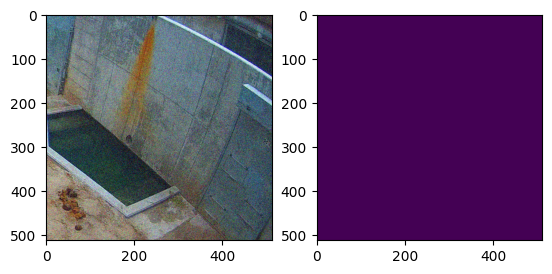

In [ ]:
import PIL.Image
from coco_panoptic_dataset import CocoPanopticDataset
from transformers import Mask2FormerImageProcessor

processor = Mask2FormerImageProcessor(
    reduce_labels=False,
    ignore_index=255,
    do_resize=False,
    do_rescale=False,
    do_normalize=False,
)

ADE_MEAN = np.array([123.675, 116.280, 103.530]) / 255
ADE_STD = np.array([58.395, 57.120, 57.375]) / 255

train_transform = A.Compose(
    [
        A.SmallestMaxSize(max_size=800),
        A.RandomCrop(width=512, height=512),
        A.HorizontalFlip(p=0.5),
        A.GaussNoise(mean_range=[0, 0], std_range=[0.1, 0.2]),
        A.Normalize(mean=ADE_MEAN, std=ADE_STD),
    ]
)

test_transform = A.Compose(
    [
        A.Resize(width=512, height=512),
        A.Normalize(mean=ADE_MEAN, std=ADE_STD),
    ]
)
ds_train = CocoPanopticDataset(
    DATASETS_ROOT / "elephants/segmentation/v1_d2_good_pan.json",
    processor,
    train_transform,
)
ds_val = CocoPanopticDataset(
    DATASETS_ROOT / "elephants/segmentation/val_coco_dan1_pan.json",
    processor,
    test_transform,
)

# Test
print(ds_train.segmentation_files[0])
item = ds_train[0]
im = item["pixel_values"].permute([1, 2, 0])
im = (im - im.min()) / (im.max() - im.min())

fig, axs = plt.subplots(1, 1 + max(1, item["mask_labels"].shape[0]))
axs[0].imshow(im)
for i, mask in enumerate(item["mask_labels"]):
    axs[i + 1].imshow(mask)
print(f"{torch.unique(item['mask_labels'])=}")
print(f"{torch.unique(item['class_labels'])=}")

In [20]:
ff = Path(
    "/home/dherrera/data/elephants/segmentation/coco/annotations/panoptic_train2017.json"
)
with ff.open() as f:
    j = json.load(f)
ff = Path(
    "/home/dherrera/data/elephants/segmentation/coco/annotations/panoptic_train2017_2.json"
)
with ff.open("w") as f:
    json.dump(j, f, indent=1)

In [21]:
from torch.utils.data import DataLoader


def collate_fn(batch):
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    pixel_mask = torch.stack([example["pixel_mask"] for example in batch])
    class_labels = [example["class_labels"] for example in batch]
    mask_labels = [example["mask_labels"] for example in batch]
    return {
        "pixel_values": pixel_values,
        "pixel_mask": pixel_mask,
        "class_labels": class_labels,
        "mask_labels": mask_labels,
    }


train_dataloader = DataLoader(
    ds_train, batch_size=4, shuffle=True, collate_fn=collate_fn
)

# Test
batch = next(iter(train_dataloader))
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)
    else:
        print(k, len(v))

pixel_values torch.Size([4, 3, 512, 512])
pixel_mask torch.Size([4, 512, 512])
class_labels 4
mask_labels 4


In [22]:
print(batch["class_labels"])

[tensor([0, 1]), tensor([0, 1, 1, 0, 0, 0, 0]), tensor([0, 1]), tensor([0])]


In [23]:
from transformers import Mask2FormerForUniversalSegmentation

# Replace the head of the pre-trained model
# We specify ignore_mismatched_sizes=True to replace the already fine-tuned classification head by a new one
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    "facebook/mask2former-swin-base-coco-instance",
    id2label={0: "background", 1: "elephant"},
    ignore_mismatched_sizes=True,
)

Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-coco-instance and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([81]) in the checkpoint and torch.Size([3]) in the model instantiated
- class_predictor.weight: found shape torch.Size([81, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([81]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import torch
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

running_loss = 0.0
num_samples = 0
for epoch in range(100):
    print("Epoch:", epoch)
    model.train()
    for idx, batch in enumerate(tqdm(train_dataloader)):
        # Reset the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            pixel_values=batch["pixel_values"].to(device),
            mask_labels=[labels.to(device) for labels in batch["mask_labels"]],
            class_labels=[labels.to(device) for labels in batch["class_labels"]],
        )

        # Backward propagation
        loss = outputs.loss
        loss.backward()

        batch_size = batch["pixel_values"].size(0)
        running_loss += loss.item()
        num_samples += batch_size

        if idx % 100 == 0:
            print("Loss:", running_loss / num_samples)

        # Optimization
        optimizer.step()

Epoch: 0


  0%|          | 0/2607 [00:00<?, ?it/s]

Loss: 16.657434463500977
Loss: 11.840428283899138
Loss: 11.480506672788023
Loss: 11.281353981391932
Loss: 10.994611907778237
Loss: 10.71595408864126
Loss: 10.576097908908634
Loss: 10.373053918041279
Loss: 10.236205728164178
Loss: 10.040602170336127
Loss: 9.873593584462242
Loss: 9.732261765501264
Loss: 9.590214012117807
Loss: 9.486322105434837
Loss: 9.354558869738991
Loss: 9.243045624298386
Loss: 9.141645582894249
Loss: 9.04667938098986
Loss: 8.963255782646314
Loss: 8.869499505224635
Loss: 8.799802724151002
Loss: 8.722544146855068
Loss: 8.62849740021232
Loss: 8.567445320494535
Loss: 8.493227830408813
Loss: 8.424237490963431
Loss: 8.360403490680678
Epoch: 1


  0%|          | 0/2607 [00:00<?, ?it/s]

Loss: 8.362269831526657
Loss: 8.290328991424124
Loss: 8.228520550774551
Loss: 8.179803087459181
Loss: 8.131363541427891
Loss: 8.088028135265157
